In [1]:
import pywswat.mikeio as mikewave
import mikeio

## Input file

In [2]:
fn_sample = r"D:\STKI\M21WFM\Examples\Ronne\Tri_irregular_3d_refined.mwfm - Result Files\area.dfsu"
ds_u = mikeio.read(fn_sample)

In [3]:
x = 479_800
y = 6_105_350
ds_0 = ds_u.sel(x=x, y=y)

Plot

<Axes: xlabel='time', ylabel='Surface elevation [m]'>

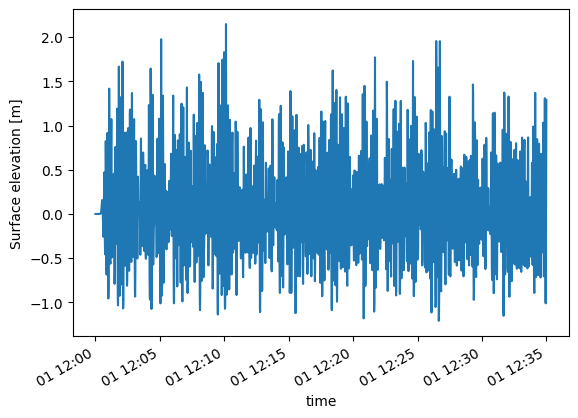

In [4]:
ds_0["Surface elevation"].plot()

## Time/space
Start/end

In [5]:
ds_0

<mikeio.Dataset>
dims: (time:2101)
time: 1990-01-01 12:00:00 - 1990-01-01 12:35:00 (2101 records)
geometry: GeometryPoint2D(x=479800.93799147784, y=6105350.950365815)
items:
  0:  Surface elevation <Surface Elevation> (meter)
  1:  Depth averaged U velocity <u velocity component> (meter per sec)
  2:  Depth averaged V velocity <v velocity component> (meter per sec)
  3:  Current speed <Current Speed> (meter per sec)

## FFT Parameters

Resolution

In [6]:
fft_size = 512

Data window

In [7]:
window_type = "hann"
overlap = 0.5

Cut-off frequency

In [8]:
f0 = None
f1 = 0.125

## Analysis

In [9]:
itm_se = "Surface elevation"
itm_u = "Depth averaged U velocity"
itm_v = "Depth averaged V velocity"

ds = mikewave.spectral_params(
    ds_0,
    elevation=itm_se,
    u=itm_u,
    v=itm_v,
    window=window_type,
    overlap=overlap,
    window_size=fft_size,
)

In [10]:
for itm in ds.items:
    print(f"{itm.name}, {ds[itm.name].values[0]:.1f} {itm.unit.display_name}")

Hm0, 2.2 meter
Tp, 8.3 second
T01, 7.6 second
T02, 7.2 second
Tm10, 8.5 second
MWD, 254.8 degree
PWD, 250.0 degree
DSD, 0.5 degree


## Extended example:
short/long waves  - seperated at 0.04 Hz (25s)

In [11]:
import pandas as pd

freqs = {
    "long": (0, 0.04),
    "short": (0.04, 1),
    "total": (0, 1),
}

df = pd.DataFrame()
for freq_type, (fmin, fmax) in freqs.items():
    ds = mikewave.spectral_params(
        ds_0,
        elevation=itm_se,
        u=itm_u,
        v=itm_v,
        window=window_type,
        overlap=overlap,
        window_size=fft_size,
        fmin=fmin,
        fmax=fmax,
    )

    df[freq_type] = ds.to_dataframe().squeeze()

In [12]:
df

,long,short,total
Hm0,0.210693,2.208074,2.218103
Tp,64.000000,8.258065,8.258065
T01,47.733485,7.535262,7.592956
T02,44.422075,7.206566,7.238432
Tm10,60.401277,8.068960,8.541137
MWD,274.298250,254.757921,254.817850
PWD,280.000000,250.000000,250.000000
DSD,1.186384,0.529198,0.539008


## as spectrum

In [16]:
ds = mikewave.spectrum(
    ds_0,
    elevation=itm_se,
    u=itm_u,
    v=itm_v,
    window=window_type,
    overlap=overlap,
    window_size=fft_size,
)

<PolarAxes: title={'center': '1990-01-01 12:00:00'}>

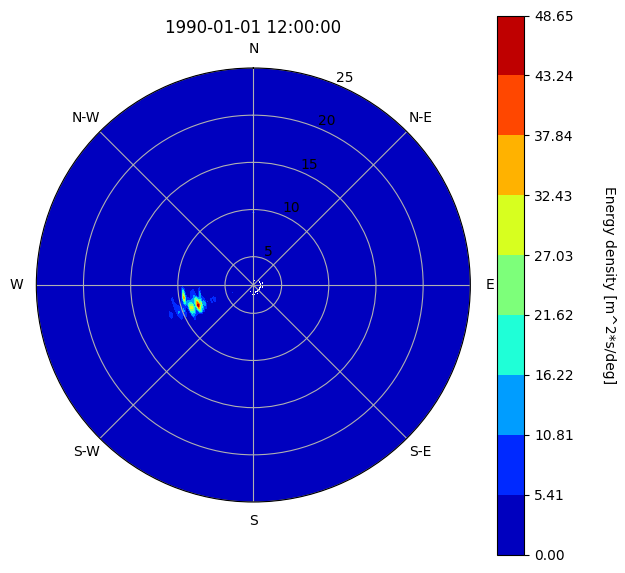

In [21]:
ds.plot(cmap="jet", rmax=25)